# TextImputer — Minimal Demo

## 1.Input text

In [1]:
TEXT = "The acting was absolutely brilliant but the plot was painfully dull."

## 2. Create TextImputer

In [ ]:
import numpy as np

from shapiq.imputer.text_imputer import TextImputer


MODEL = "distilbert-base-uncased-finetuned-sst-2-english"

imputer = TextImputer(
    model_name=MODEL,
    input_text=TEXT,
    mask_strategy="mask", #try also "remove"
    batch_size=16,
    segmentation="token" #try also "word"
)

print("Number of tokens (players):", imputer.n_features)
#raw token ids
print("Token IDs: ", imputer.tokens)

#how tokens look like
token_strings = imputer._tokenizer.convert_ids_to_tokens(imputer.tokens)
print("Tokens (String):", token_strings)

#the classification of the input by calling the MODEL
print(imputer._classifier(imputer.original_text))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Number of tokens (players): 12
Token IDs:  [ 1996  3772  2001  7078  8235  2021  1996  5436  2001 16267 10634  1012]
Tokens (String): ['the', 'acting', 'was', 'absolutely', 'brilliant', 'but', 'the', 'plot', 'was', 'painfully', 'dull', '.']
[{'label': 'NEGATIVE', 'score': 0.9996864795684814}]


## 3. Explain the Imputer & compute shapley values

In [4]:
from shapiq.game_theory.exact import ExactComputer

computer = ExactComputer(imputer)

sv = computer(index="SV")


## 4.Visualization (e.g. sentence plot)

In [5]:
print(f"{'token':<20} {'SV':>10}")
print("-" * 32)

for tok, val in zip(imputer.tokens, sv.values):
    print(f"{tok:<20} {val:>+10.4f}")

token                        SV
--------------------------------
1996                    +0.0000
3772                    -0.0369
2001                    -0.0945
7078                    -0.0681
8235                    +0.3157
2021                    +0.5868
1996                    -0.3099
5436                    -0.0691
2001                    -0.1749
16267                   -0.0818
10634                   -0.3171
1012                    -0.6421


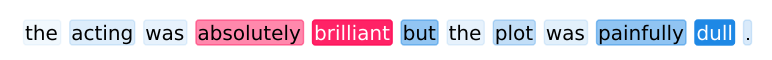

In [6]:
from shapiq.plot.sentence import sentence_plot

fig, ax = sentence_plot(
    sv,
    token_strings,
    chars_per_line=100,
    show=False
)

import matplotlib.pyplot as plt
plt.show()